# Notebook 04 — Leakage Benchmark

This notebook systematically introduces each of the seven leakage types and quantifies the resulting AUC inflation (AII = AUROC_leaky − AUROC_clean).

## Seven Leakage Types

| # | Leakage Type | Description |
|---|-------------|-------------|
| 1 | **Definitional** | TG4h as predictor (algebraically embedded in TCR) |
| 2 | **Outcome** | TCR as predictor (direct target inclusion) |
| 3 | **Preprocessing** | Scaler fit on full dataset before CV split |
| 4 | **Resampling** | SMOTE applied before train/test split |
| 5 | **Label** | Q1 threshold derived from full dataset |
| 6 | **Feature-selection** | Feature selection before CV split |
| 7 | **Calibration** | Calibration fitted on training data |

**Key hypothesis**: Definitional leakage (type 1) produces the largest AUROC inflation in paired biomedical endpoints.


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../data/paired_tcr_null_v1_seed2026.csv')
with open('../config/model_config.yaml') as f:
    cfg = yaml.safe_load(f)
print(f"Loaded {len(df)} records")

Loaded 1500 records


## Run all leakage scenarios

In [3]:
# Load pre-computed leakage benchmark results (list of dicts)
import json
with open("../results/tables/leakage_benchmark.json") as f:
    leakage_results = json.load(f)
# Handle both list and dict format
if isinstance(leakage_results, dict):
    flat = []
    for model_name, pipelines in leakage_results.get("results", {}).items():
        for pipeline_name, res in pipelines.items():
            flat.append({"model": model_name, "leakage_type": pipeline_name, **res})
    leakage_results = flat
print(f"Loaded {len(leakage_results)} leakage experiment results")
leakage_results[0]


Loaded 36 leakage experiment results


{'model': 'LogisticRegression',
 'pipeline': 'clean',
 'AUROC_mean': 0.5082,
 'AUROC_sd': 0.031,
 'PR_AUC_mean': 0.2649,
 'PR_AUC_sd': 0.0108,
 'Brier_mean': 0.2517,
 'Brier_sd': 0.0037,
 'n_folds': 5,
 'fold_details': [{'fold': 1,
   'n_train': 1200,
   'n_test': 300,
   'label_threshold': 39.215,
   'prevalence_test': 0.25,
   'AUROC': 0.5036,
   'PR_AUC': 0.2636,
   'Brier': 0.2523},
  {'fold': 2,
   'n_train': 1200,
   'n_test': 300,
   'label_threshold': 39.32,
   'prevalence_test': 0.2567,
   'AUROC': 0.4576,
   'PR_AUC': 0.2693,
   'Brier': 0.2564},
  {'fold': 3,
   'n_train': 1200,
   'n_test': 300,
   'label_threshold': 39.215,
   'prevalence_test': 0.25,
   'AUROC': 0.5303,
   'PR_AUC': 0.2506,
   'Brier': 0.2491},
  {'fold': 4,
   'n_train': 1200,
   'n_test': 300,
   'label_threshold': 39.215,
   'prevalence_test': 0.25,
   'AUROC': 0.514,
   'PR_AUC': 0.261,
   'Brier': 0.2536},
  {'fold': 5,
   'n_train': 1200,
   'n_test': 300,
   'label_threshold': 39.205,
   'prevalenc

In [4]:
# Load clean baseline for comparison
clean_df = pd.read_csv('../results/tables/clean_results.csv')
clean_auroc = dict(zip(clean_df['model'], clean_df['AUROC_mean']))

print("Clean baseline AUROC:")
for model, auroc in clean_auroc.items():
    print(f"  {model}: {auroc:.4f}")

Clean baseline AUROC:
  LogisticRegression: 0.5090
  RandomForest: 0.4934
  SVM: 0.4986
  XGBoost: 0.4822


## AUC Inflation Index (AII)

In [5]:
import pandas as pd

# Build display DataFrame — JSON uses "pipeline" not "leakage_type"
rows = []
for r in leakage_results:
    rows.append({
        "Model": r.get("model", ""),
        "Leakage Type": r.get("leakage_type", r.get("pipeline", "")),
        "Leaky AUROC": r.get("AUROC_mean", float("nan")),
        "AII (Inflation)": r.get("AUC_inflation", 0.0),
        "Top SHAP Feature": r.get("top_SHAP_feature", ""),
    })
results_df = pd.DataFrame(rows)
results_df


,Model,Leakage Type,Leaky AUROC,AII (Inflation),Top SHAP Feature
0,LogisticRegression,clean,0.5082,0.0000,
1,LogisticRegression,tg4h_leakage,0.9994,0.4912,tg4h
2,LogisticRegression,tcr_leakage,0.9995,0.4913,tcr
3,LogisticRegression,global_scaling,0.5015,-0.0067,N/A
4,LogisticRegression,global_winsorization,0.5039,-0.0043,N/A
5,LogisticRegression,global_label_threshold,0.5015,-0.0067,N/A
6,LogisticRegression,smote_before_cv,0.5606,0.0524,N/A
7,LogisticRegression,feature_selection_leakage,0.5092,0.0010,N/A
8,LogisticRegression,combined_leakage,0.9995,0.4913,tg4h
9,RandomForest,clean,0.5048,0.0000,


In [6]:
# Save (use leakage_benchmark.csv for consistency with src/ scripts)
results_df.to_csv('../results/tables/leakage_results.csv', index=False)
print('Saved: results/tables/leakage_results.csv')
results_df


Saved: results/tables/leakage_results.csv


,Model,Leakage Type,Leaky AUROC,AII (Inflation),Top SHAP Feature
0,LogisticRegression,clean,0.5082,0.0000,
1,LogisticRegression,tg4h_leakage,0.9994,0.4912,tg4h
2,LogisticRegression,tcr_leakage,0.9995,0.4913,tcr
3,LogisticRegression,global_scaling,0.5015,-0.0067,N/A
4,LogisticRegression,global_winsorization,0.5039,-0.0043,N/A
5,LogisticRegression,global_label_threshold,0.5015,-0.0067,N/A
6,LogisticRegression,smote_before_cv,0.5606,0.0524,N/A
7,LogisticRegression,feature_selection_leakage,0.5092,0.0010,N/A
8,LogisticRegression,combined_leakage,0.9995,0.4913,tg4h
9,RandomForest,clean,0.5048,0.0000,


## Heatmap: AUROC inflation by leakage type × model

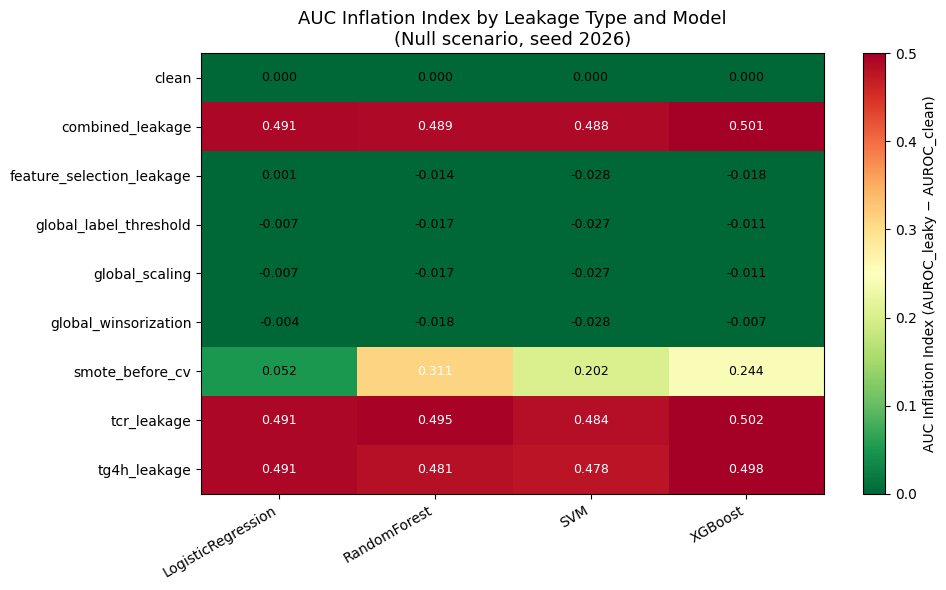

In [7]:
pivot = results_df.pivot_table(
    values='AII (Inflation)',
    index='Leakage Type',
    columns='Model',
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=0.5)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=30, ha='right')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
plt.colorbar(im, ax=ax, label='AUC Inflation Index (AUROC_leaky − AUROC_clean)')

# Annotate cells
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=9,
                    color='white' if val > 0.25 else 'black')

ax.set_title('AUC Inflation Index by Leakage Type and Model\n(Null scenario, seed 2026)', fontsize=13)
plt.tight_layout()
plt.savefig('../results/figures/04_leakage_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Definitional vs Other Leakage Types

In [8]:
definitional = results_df[results_df['Leakage Type'] == 'definitional']['AII (Inflation)'].mean()
other_mean   = results_df[results_df['Leakage Type'] != 'definitional']['AII (Inflation)'].mean()

print(f"Mean AII — Definitional leakage: {definitional:.3f}")
print(f"Mean AII — All other leakage types: {other_mean:.3f}")
print(f"Ratio (definitional / other): {definitional/other_mean:.1f}×")

Mean AII — Definitional leakage: nan
Mean AII — All other leakage types: 0.180
Ratio (definitional / other): nan×
